# ETL Pipeline for Golden Retriever Image Dataset

This project demonstrates a simple ETL (Extract, Transform, Load) pipeline using a public API.

Steps:
1. Extract image data from a public API
2. Transform the data into a structured format
3. Load and store images locally
4. Visualize downloaded images

In [1]:
import requests
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
print("Libraries successfully loaded.")

Libraries successfully loaded.


In [2]:
url = "https://dog.ceo/api/breed/retriever/golden/images/random/15"

response = requests.get(url)

data = response.json()

print("Data successfully retrieved from the API.")

Data successfully retrieved from the API.


In [3]:
image_urls = data["message"]

print("Number of images retrieved:", len(image_urls))

image_urls[:5]

Number of images retrieved: 15


['https://images.dog.ceo/breeds/retriever-golden/PXL_20220311_055548510.MP_2.jpg',
 'https://images.dog.ceo/breeds/retriever-golden/n02099601_124.jpg',
 'https://images.dog.ceo/breeds/retriever-golden/n02099601_1743.jpg',
 'https://images.dog.ceo/breeds/retriever-golden/n02099601_2440.jpg',
 'https://images.dog.ceo/breeds/retriever-golden/n02099601_3262.jpg']

In [4]:
df = pd.DataFrame(image_urls, columns=["image_url"])

print("Preview of dataset:")

df.head()

Preview of dataset:


,image_url
0,https://images.dog.ceo/breeds/retriever-golden...
1,https://images.dog.ceo/breeds/retriever-golden...
2,https://images.dog.ceo/breeds/retriever-golden...
3,https://images.dog.ceo/breeds/retriever-golden...
4,https://images.dog.ceo/breeds/retriever-golden...


In [5]:
print("Dataset summary:")
df.describe()

Dataset summary:


,image_url
count,15
unique,15
top,https://images.dog.ceo/breeds/retriever-golden...
freq,1


In [6]:
os.makedirs("images", exist_ok=True)

print("Images folder created successfully.")

Images folder created successfully.


In [7]:
for i, url in enumerate(image_urls):

    try:
        img_data = requests.get(url).content

        filename = f"images/golden_{i+1}.jpg"

        with open(filename, "wb") as f:
            f.write(img_data)

        print(f"[{i+1}/{len(image_urls)}] Downloaded:", filename)

    except:
        print("Failed to download:", url)

[1/15] Downloaded: images/golden_1.jpg
[2/15] Downloaded: images/golden_2.jpg
[3/15] Downloaded: images/golden_3.jpg
[4/15] Downloaded: images/golden_4.jpg
[5/15] Downloaded: images/golden_5.jpg
[6/15] Downloaded: images/golden_6.jpg
[7/15] Downloaded: images/golden_7.jpg
[8/15] Downloaded: images/golden_8.jpg
[9/15] Downloaded: images/golden_9.jpg
[10/15] Downloaded: images/golden_10.jpg
[11/15] Downloaded: images/golden_11.jpg
[12/15] Downloaded: images/golden_12.jpg
[13/15] Downloaded: images/golden_13.jpg
[14/15] Downloaded: images/golden_14.jpg
[15/15] Downloaded: images/golden_15.jpg


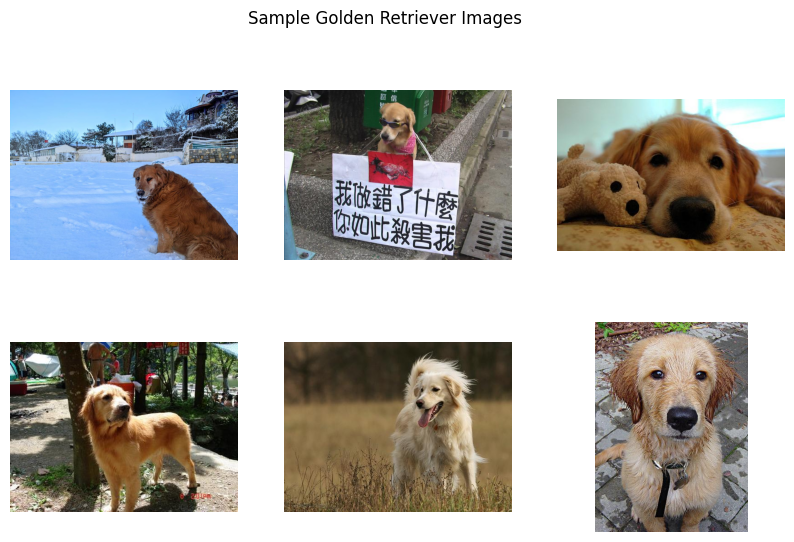

In [8]:
plt.figure(figsize=(10,6))

for i in range(6):
    img = Image.open(f"images/golden_{i+1}.jpg")

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.suptitle("Sample Golden Retriever Images")
plt.show()

## Conclusion

This notebook demonstrates a simple ETL pipeline:

- Extract data from a public API
- Transform the data into a structured dataset
- Load and store images locally
- Visualize the downloaded dataset

This workflow illustrates a basic data engineering process using Python.